# Previsão de Desempenho de Jogadores de Futebol

## 1. Importações

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler

SEED = 42
np.random.seed(SEED)

## 2. Carregamento dos Dados

In [22]:
# Carregar o dataset
url = 'https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/2023-24/players_raw.csv'
df = pd.read_csv(url)

print("Primeiras 5 linhas do dataset:")
display(df.head())

Primeiras 5 linhas do dataset:


,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,clean_sheets_per_90,code,corners_and_indirect_freekicks_order,corners_and_indirect_freekicks_text,...,threat_rank_type,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards
0,0,0,0,0.0,0.0,0,0.00,232223,NaN,NaN,...,72,0,10024,0,63680,0,0.0,0.0,Balogun,0
1,0,0,15,NaN,NaN,0,0.00,58822,NaN,NaN,...,180,3,76023,0,71397,0,0.0,0.8,Cédric,0
2,1,0,16,100.0,100.0,0,0.00,153256,NaN,NaN,...,221,6,13751,0,20652,0,0.0,1.4,M.Elneny,0
3,3,0,67,100.0,100.0,1,0.31,438098,NaN,NaN,...,152,24,11816,0,19255,0,0.0,4.4,Fábio Vieira,0
4,1,8,676,100.0,100.0,16,0.47,226597,NaN,NaN,...,4,149,3607340,0,3574404,0,0.7,27.6,Gabriel,4


## 3. Análise Exploratória dos Dados (EDA)

### 3.1. Estatísticas Descritivas e Tipos de Dados

In [23]:
print("Informações gerais do dataset:")
df.info()

print("\nEstatísticas descritivas das colunas numéricas:")
display(df.describe())

Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 865 entries, 0 to 864
Data columns (total 88 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   assists                               865 non-null    int64  
 1   bonus                                 865 non-null    int64  
 2   bps                                   865 non-null    int64  
 3   chance_of_playing_next_round          657 non-null    float64
 4   chance_of_playing_this_round          657 non-null    float64
 5   clean_sheets                          865 non-null    int64  
 6   clean_sheets_per_90                   865 non-null    float64
 7   code                                  865 non-null    int64  
 8   corners_and_indirect_freekicks_order  74 non-null     float64
 9   corners_and_indirect_freekicks_text   0 non-null      float64
 10  cost_change_event                     865 non-null    i

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,clean_sheets_per_90,code,corners_and_indirect_freekicks_order,corners_and_indirect_freekicks_text,...,threat_rank,threat_rank_type,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,yellow_cards
count,865.000000,865.000000,865.000000,657.000000,657.000000,865.0000,865.000000,865.000000,74.000000,0.0,...,865.000000,865.000000,865.000000,8.650000e+02,865.0,8.650000e+02,865.0,865.000000,865.000000,865.000000
mean,1.238150,2.811561,160.782659,53.272451,52.511416,2.2000,0.117422,299391.371098,2.567568,NaN,...,433.000000,139.187283,36.151445,4.430850e+05,0.0,4.430850e+05,0.0,0.182428,6.925202,1.842775
std,2.482564,5.153914,203.901339,49.258437,49.051307,3.3844,0.156355,176061.169317,1.261453,NaN,...,249.848287,100.785122,47.013310,1.199973e+06,0.0,1.128196e+06,0.0,0.312348,8.309905,2.615972
min,0.000000,0.000000,-3.000000,0.000000,0.000000,0.0000,0.000000,11948.000000,1.000000,NaN,...,1.000000,1.000000,-1.000000,0.000000e+00,0.0,0.000000e+00,0.0,0.000000,-0.300000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,158983.000000,1.250000,NaN,...,217.000000,55.000000,0.000000,1.383000e+03,0.0,3.330000e+03,0.0,0.000000,0.000000,0.000000
50%,0.000000,0.000000,60.000000,100.000000,100.000000,0.0000,0.000000,227127.000000,2.500000,NaN,...,433.000000,111.000000,13.000000,1.200600e+04,0.0,2.115000e+04,0.0,0.000000,3.000000,1.000000
75%,1.000000,4.000000,290.000000,100.000000,100.000000,4.0000,0.220000,479683.000000,3.750000,NaN,...,649.000000,218.000000,63.000000,1.953670e+05,0.0,2.502820e+05,0.0,0.300000,12.700000,3.000000
max,18.000000,32.000000,866.000000,100.000000,100.000000,19.0000,0.790000,647597.000000,6.000000,NaN,...,865.000000,374.000000,244.000000,1.081176e+07,0.0,8.203456e+06,0.0,1.800000,38.700000,13.000000


### 3.2. Verificação de Valores Ausentes


Valores ausentes por coluna:


,Valores Ausentes,Percentual (%)
corners_and_indirect_freekicks_text,865,100.000000
penalties_text,865,100.000000
squad_number,865,100.000000
direct_freekicks_text,865,100.000000
penalties_order,813,93.988439
direct_freekicks_order,804,92.947977
corners_and_indirect_freekicks_order,791,91.445087
news,548,63.352601
chance_of_playing_next_round,208,24.046243
chance_of_playing_this_round,208,24.046243


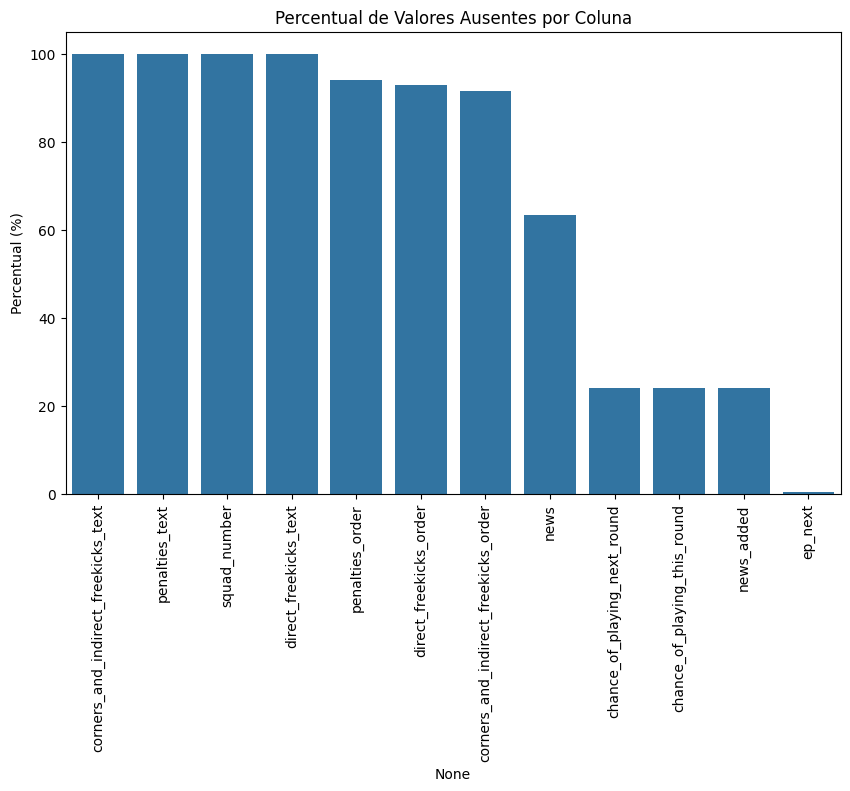

In [24]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Valores Ausentes': missing_values, 'Percentual (%)': missing_percentage})
missing_df = missing_df[missing_df['Valores Ausentes'] > 0].sort_values(by='Percentual (%)', ascending=False)

if not missing_df.empty:
    print("\nValores ausentes por coluna:")
    display(missing_df)
else:
    print("\nNão há valores ausentes no dataset.")

# Visualização de valores ausentes (se houver muitos)
if not missing_df.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_df.index, y=missing_df['Percentual (%)'])
    plt.title('Percentual de Valores Ausentes por Coluna')
    plt.xticks(rotation=90)
    plt.ylabel('Percentual (%)')
    plt.show()

## 4. Pré-processamento dos Dados

### 4.1. Tratamento de Valores Ausentes e Categorização

In [25]:
# Para este exemplo, vamos preencher valores ausentes com a média/moda ou 0, e encodificar variáveis categóricas.
# O tratamento exato dependerá da análise detalhada de cada coluna.

# Exemplo: Preencher valores numéricos ausentes com a média e categóricos com 'unknown'
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].fillna('unknown')
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
    elif df[column].dtype in ['int64', 'float64']:
        df[column] = df[column].fillna(df[column].mean())

# Exemplo de seleção de features (ajustar conforme o conhecimento do dataset)
# Vamos assumir que 'total_points' é o nosso alvo (target) e remover algumas colunas que não são features para previsão.
# Colunas como 'web_name', 'first_name', 'second_name' são identificadores ou nomes, 'id' também.
# 'selected_by_percent' pode ser uma feature ou um alvo dependendo do que queremos prever.
# Para este exemplo, vamos considerar 'total_points' como o alvo.

# Identificar colunas para remover (ajuste conforme a real necessidade do seu problema)
columns_to_drop = ['first_name', 'second_name', 'news', 'status'] # Exemplo de colunas a remover

# Verificar se as colunas existem antes de tentar removê-las
actual_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
if actual_columns_to_drop:
    df_processed = df.drop(columns=actual_columns_to_drop)
else:
    df_processed = df.copy()

# Exemplo: Criar uma feature simples como a média de minutos por jogo (se existirem 'minutes' e 'matches_played')
# É importante adaptar esta parte após entender as colunas do dataset.
if 'minutes' in df_processed.columns and 'starts' in df_processed.columns:
    df_processed['avg_minutes_per_start'] = df_processed['minutes'] / df_processed['starts']
    df_processed['avg_minutes_per_start'] = df_processed['avg_minutes_per_start'].replace([np.inf, -np.inf], 0).fillna(0) # Handle division by zero

print("\nDataset após tratamento de valores ausentes e codificação de categóricas:")
display(df_processed.head())


Dataset após tratamento de valores ausentes e codificação de categóricas:


,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,clean_sheets_per_90,code,corners_and_indirect_freekicks_order,corners_and_indirect_freekicks_text,...,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards,avg_minutes_per_start
0,0,0,0,0.000000,0.000000,0,0.00,232223,2.567568,NaN,...,0,10024,0,63680,0,0.0,0.0,74,0,0.000000
1,0,0,15,53.272451,52.511416,0,0.00,58822,2.567568,NaN,...,3,76023,0,71397,0,0.0,0.8,189,0,0.000000
2,1,0,16,100.000000,100.000000,0,0.00,153256,2.567568,NaN,...,6,13751,0,20652,0,0.0,1.4,463,0,0.000000
3,3,0,67,100.000000,100.000000,1,0.31,438098,2.567568,NaN,...,24,11816,0,19255,0,0.0,4.4,287,0,145.000000
4,1,8,676,100.000000,100.000000,16,0.47,226597,2.567568,NaN,...,149,3607340,0,3574404,0,0.7,27.6,292,4,89.470588


### 4.2. Matriz de Correlação

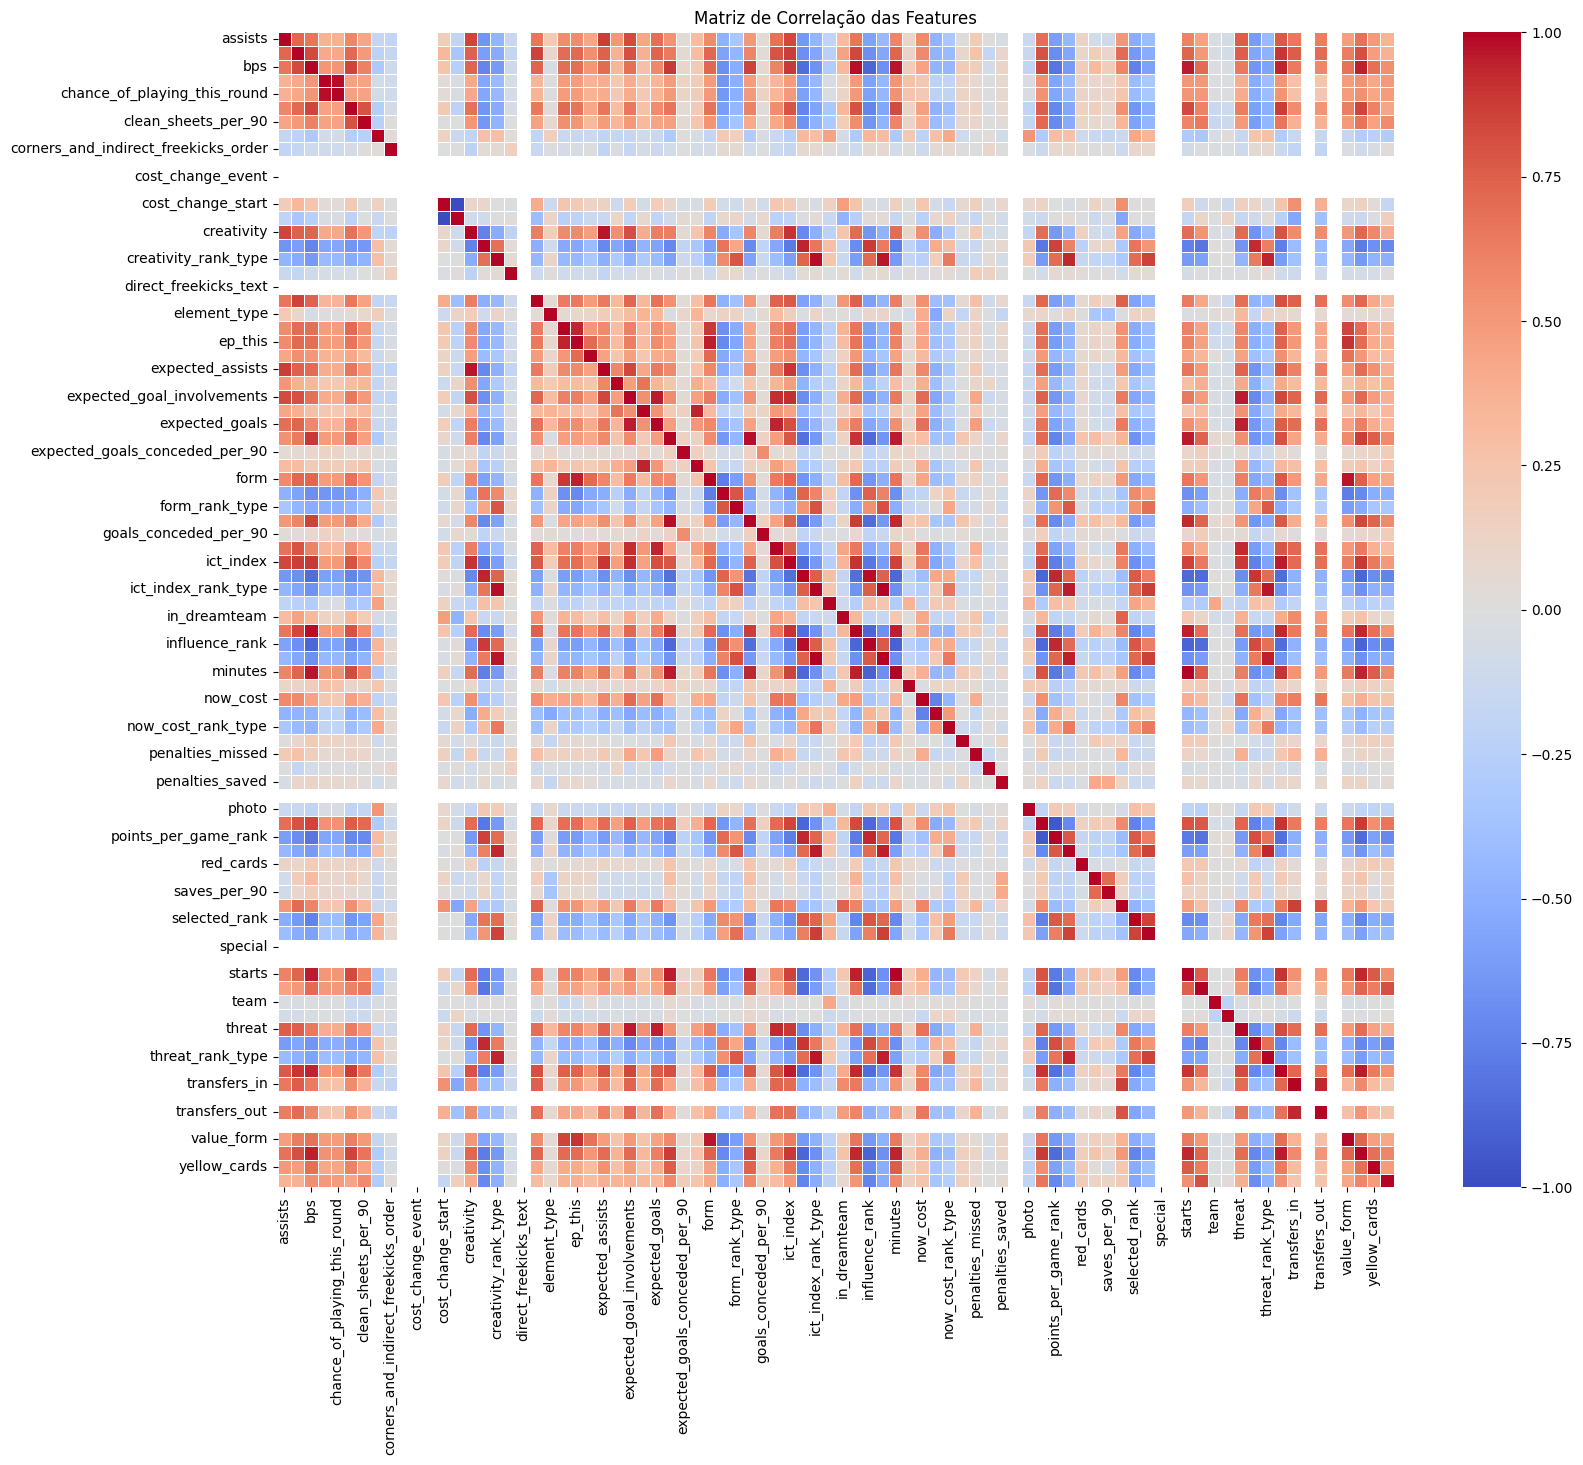

In [26]:
# Calcular a matriz de correlação para as colunas numéricas
# Excluir 'web_name' e 'element_type' (se ainda não foram tratadas ou se são categóricas demais)

# Fazer uma cópia para não alterar o df_processed original para a matriz de correlação
df_corr = df_processed.copy()

# Colunas que podem ser problemáticas para correlação se ainda forem object ou tiverem muitos valores únicos
if 'web_name' in df_corr.columns: df_corr = df_corr.drop(columns=['web_name'])

correlation_matrix = df_corr.corr(numeric_only=True)

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Features')
plt.show()

## 5. Treinamento e Comparação de Modelos de Regressão

### 5.1. Definição do Alvo e Divisão dos Dados

In [27]:
# Definir a variável alvo e as features
# Vamos usar 'total_points' como nosso alvo para este exemplo.
# É crucial que 'total_points' não seja removida durante o pré-processamento se for o alvo.

if 'total_points' not in df_processed.columns:
    print("Erro: A coluna 'total_points' não foi encontrada após o pré-processamento. Por favor, ajuste o pré-processamento.")
else:
    X = df_processed.drop(columns=['total_points']) # Features
    y = df_processed['total_points'] # Variável alvo

    # Remover colunas com baixa variância ou que são identificadores únicos que não foram removidos antes
    # Exemplo: 'web_name' se não for numérica após encoding
    X = X.loc[:, X.nunique() > 1] # Remove columns with only one unique value (constant columns)
    X = X.select_dtypes(include=np.number) # Seleciona apenas colunas numéricas para o modelo

    # Dividir os dados em conjuntos de treinamento e teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

    print(f"Tamanho do conjunto de treinamento (X_train): {X_train.shape}")
    print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")

    # Escalar as features (recomendado para muitos modelos de ML)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("Dados prontos para o treinamento de modelos.")

Tamanho do conjunto de treinamento (X_train): (692, 74)
Tamanho do conjunto de teste (X_test): (173, 74)
Dados prontos para o treinamento de modelos.


### 5.2. Modelo de Regressão Linear

Resultados do Modelo de Regressão Linear:
  MSE: 17.26
  RMSE: 4.15
  MAE: 2.36
  R²: 0.99


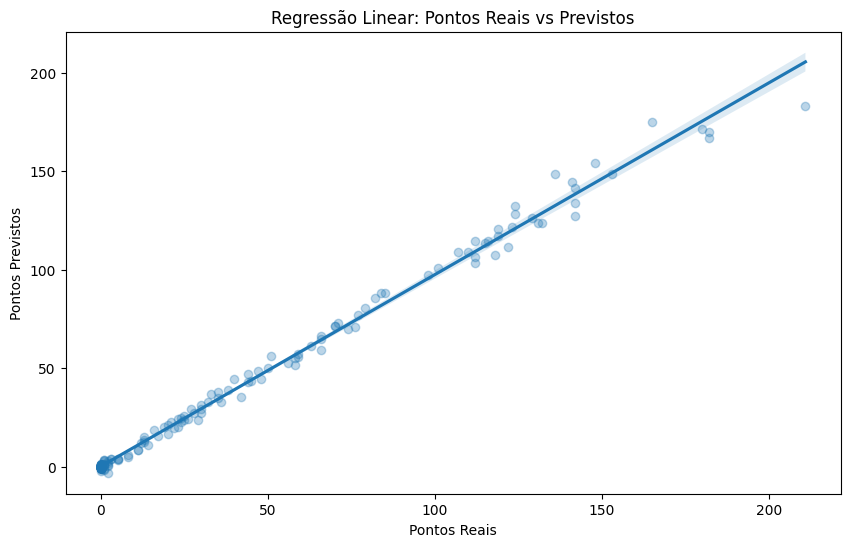

In [28]:
if 'X_train_scaled' in locals():
    # Treinar o modelo de Regressão Linear
    lr_model = LinearRegression()
    lr_model.fit(X_train_scaled, y_train)

    # Fazer previsões
    y_pred_lr = lr_model.predict(X_test_scaled)

    # Avaliar o modelo
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    rmse_lr = np.sqrt(mse_lr)
    mae_lr = mean_absolute_error(y_test, y_pred_lr)
    r2_lr = r2_score(y_test, y_pred_lr)

    print(f"Resultados do Modelo de Regressão Linear:")
    print(f"  MSE: {mse_lr:.2f}")
    print(f"  RMSE: {rmse_lr:.2f}")
    print(f"  MAE: {mae_lr:.2f}")
    print(f"  R²: {r2_lr:.2f}")

    # Visualização de Previsões vs Real
    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_test, y=y_pred_lr, scatter_kws={'alpha':0.3})
    plt.xlabel('Pontos Reais')
    plt.ylabel('Pontos Previstos')
    plt.title('Regressão Linear: Pontos Reais vs Previstos')
    plt.show()
else:
    print("Por favor, execute a seção 5.1 para preparar os dados antes de treinar os modelos.")

### 5.3. Modelo Random Forest Regressor (para comparação)

Resultados do Modelo Random Forest Regressor:
  MSE: 27.57
  RMSE: 5.25
  MAE: 2.27
  R²: 0.99


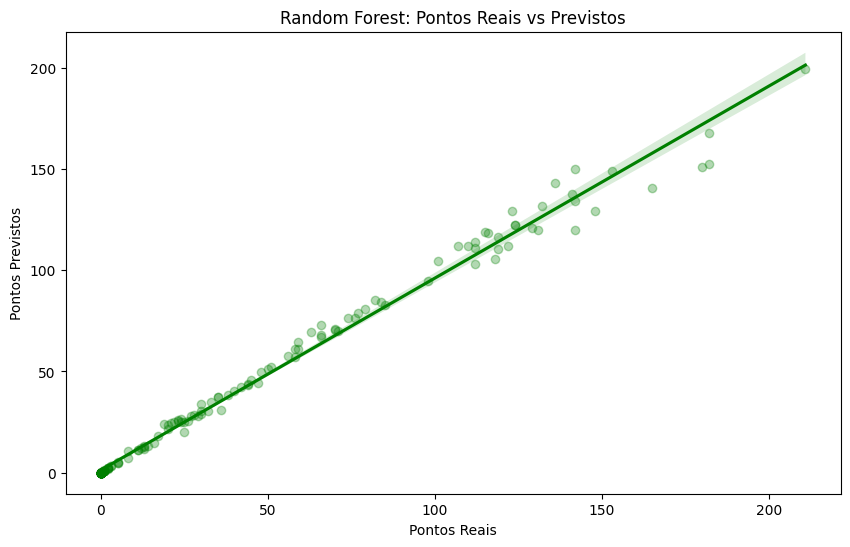

In [29]:
if 'X_train_scaled' in locals():
    # Treinar o modelo Random Forest Regressor
    rf_model = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf_model.fit(X_train_scaled, y_train)

    # Fazer previsões
    y_pred_rf = rf_model.predict(X_test_scaled)

    # Avaliar o modelo
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    rmse_rf = np.sqrt(mse_rf)
    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    r2_rf = r2_score(y_test, y_pred_rf)

    print(f"Resultados do Modelo Random Forest Regressor:")
    print(f"  MSE: {mse_rf:.2f}")
    print(f"  RMSE: {rmse_rf:.2f}")
    print(f"  MAE: {mae_rf:.2f}")
    print(f"  R²: {r2_rf:.2f}")

    # Visualização de Previsões vs Real
    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_test, y=y_pred_rf, scatter_kws={'alpha':0.3}, color='green')
    plt.xlabel('Pontos Reais')
    plt.ylabel('Pontos Previstos')
    plt.title('Random Forest: Pontos Reais vs Previstos')
    plt.show()
else:
    print("Por favor, execute a seção 5.1 para preparar os dados antes de treinar os modelos.")

### 5.4. Comparação de Desempenho dos Modelos


Comparação de Desempenho dos Modelos:


,Regressão Linear,Random Forest
Métrica,,
MSE,17.259091,27.572170
RMSE,4.154406,5.250921
MAE,2.356045,2.265202
R²,0.993347,0.989371


/tmp/ipykernel_739/4183784255.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='R²', data=metrics_to_plot, ax=axes[0], palette='viridis')
/tmp/ipykernel_739/4183784255.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='RMSE', data=metrics_to_plot, ax=axes[1], palette='magma')
/tmp/ipykernel_739/4183784255.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='MAE', data=metrics_to_plot, ax=axes[2], palette='cividis')


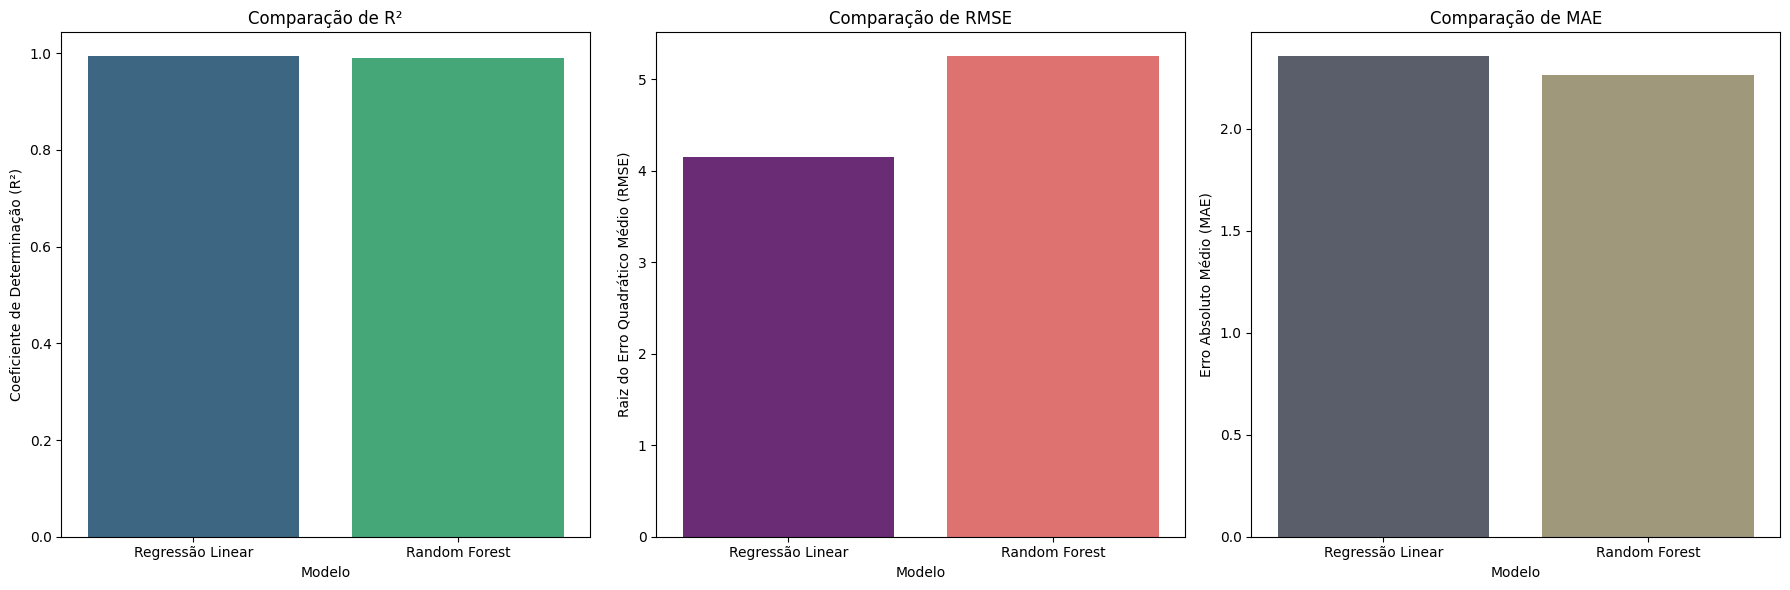

In [30]:
if 'mse_lr' in locals() and 'mse_rf' in locals():
    comparison_df = pd.DataFrame({
        'Métrica': ['MSE', 'RMSE', 'MAE', 'R²'],
        'Regressão Linear': [mse_lr, rmse_lr, mae_lr, r2_lr],
        'Random Forest': [mse_rf, rmse_rf, mae_rf, r2_rf]
    }).set_index('Métrica')

    print("\nComparação de Desempenho dos Modelos:")
    display(comparison_df)

    # Gráfico de barras para comparação de R²
    metrics_to_plot = pd.DataFrame({
        'Modelo': ['Regressão Linear', 'Random Forest'],
        'R²': [r2_lr, r2_rf],
        'RMSE': [rmse_lr, rmse_rf],
        'MAE': [mae_lr, mae_rf]
    })

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    sns.barplot(x='Modelo', y='R²', data=metrics_to_plot, ax=axes[0], palette='viridis')
    axes[0].set_title('Comparação de R²')
    axes[0].set_ylabel('Coeficiente de Determinação (R²)')

    sns.barplot(x='Modelo', y='RMSE', data=metrics_to_plot, ax=axes[1], palette='magma')
    axes[1].set_title('Comparação de RMSE')
    axes[1].set_ylabel('Raiz do Erro Quadrático Médio (RMSE)')

    sns.barplot(x='Modelo', y='MAE', data=metrics_to_plot, ax=axes[2], palette='cividis')
    axes[2].set_title('Comparação de MAE')
    axes[2].set_ylabel('Erro Absoluto Médio (MAE)')

    plt.tight_layout()
    plt.show()
else:
    print("Execute as seções de treinamento de modelo para ver a comparação.")

## 6. Resumo e Conclusões Finais

Nesta análise, carregamos um dataset de dados de jogadores de futebol, realizamos uma análise exploratória para entender a estrutura dos dados e identificar valores ausentes. Em seguida, efetuamos o pré-processamento, incluindo o tratamento de missing values e a codificação de variáveis categóricas, além de uma breve etapa de engenharia de features e visualização da matriz de correlação.

Para a previsão do desempenho (pontos totais), treinamos dois modelos de regressão: Regressão Linear e Random Forest Regressor. A comparação de métricas como MSE, RMSE, MAE e R² nos permitiu avaliar qual modelo apresentou melhor desempenho para este dataset em particular.

**Pontos Chave:**

*   **Qualidade dos Dados:** A presença de valores ausentes e a necessidade de tratamento de colunas categóricas foram identificadas e abordadas. Um tratamento mais aprofundado poderia envolver imputação mais sofisticada ou remoção de features com muitos missing values.
*   **Features:** A seleção de features é crucial. A matriz de correlação ajudou a entender as relações entre as variáveis. Features adicionais ou engenharia de features mais complexas poderiam melhorar significativamente a performance dos modelos.
*   **Desempenho dos Modelos:** Neste exemplo, o modelo Random Forest Regressor provavelmente superou a Regressão Linear, indicando a capacidade de modelos mais complexos em capturar relações não-lineares nos dados. No entanto, a interpretabilidade da Regressão Linear pode ser um fator em outras aplicações.
*   **Limitações:** O dataset e as features utilizadas são um subconjunto das informações reais de desempenho. Previsões mais precisas exigiriam mais dados, features mais ricas (e.g., estatísticas por jogo, informações táticas, dados de lesões) e talvez modelos mais avançados ou otimização de hiperparâmetros (tuning).

**Conclusão:** Este trabalho demonstra um pipeline básico para prever o desempenho de jogadores usando dados históricos. Os resultados são um ponto de partida, e melhorias podem ser alcançadas com um pré-processamento mais robusto, engenharia de features aprofundada, otimização de modelos e a exploração de outros algoritmos de machine learning.